# Imports

In [35]:
%load_ext autoreload
%autoreload 2

# System functionality
import os
import glob 
from pathlib import Path
import json

import config

# Data Analysis
import xarray as xr
# from windspharm.standard import VectorWind
# from windspharm.tools import prep_data, recover_data, order_latdim
import xeofs as xe
# import xesmf
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec
from matplotlib import colors as mcolors
from matplotlib import ticker as mticker
from matplotlib import colormaps

# Cartopy
from cartopy import crs as ccrs
from cartopy import feature as cfeature
from cartopy import util as cutil
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter, LongitudeLocator, LatitudeLocator

# Auxiliary Functions
from auxiliary_functions.time_utils import datetime64_to_yyyymmdd, string_to_yyyymm, convert_time_to_ns, convert_ns_to_datetime, extract_years_months, datetime64_to_ns
from auxiliary_functions import xarray_utils
from auxiliary_functions.plotting_utils import tick_labeller, set_plot_mode, get_figsize
from auxiliary_functions.logging_utils import CombinedTimeFormatter
# from auxiliary_functions.calculate_velocity_potential import calculate_velocity_potential_graphcast

# Logging
import logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
)
logger = logging.getLogger(__name__)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# start_date = "2020-12-29T00:00:00.000000000"
# end_date = "2021-02-27T00:00:00.000000000"
# logger.info(f"Start date: {start_date}")
# logger.info(f"End date: {end_date}")

# logger.info("Starting data download script")
# def surface_level_preprocess(ds: xr.Dataset) -> xr.Dataset:
#     # Subset to a specific region and keep only one variable
#     subset_data = ds.sel(
#         # level=pressure_levels,
#         time=ds.time.where(ds['time'].dt.hour.isin([0, 6, 12, 18]), drop=True)
#     )

#     target_grid = xr.Dataset(
#         {
#             "lat": (["lat"], np.arange(-90, 91, 1.0)),
#             "lon": (["lon"], np.arange(0, 360, 1.0)),
#         }
#     )
#     regridder = xe.Regridder(subset_data, target_grid, "bilinear", reuse_weights=False) 

#     return regridder(subset_data) # type: ignore

# def pressure_level_preprocess(ds: xr.Dataset) -> xr.Dataset:
#     # Subset to a specific region and keep only one variable
#     subset_data = ds.sel(
#         level=pressure_levels,
#         time=ds.time.where(ds['time'].dt.hour.isin([0, 6, 12, 18]), drop=True)
#     ).assign_coords({'level': pressure_levels.astype(np.int32)})

#     target_grid = xr.Dataset(
#         {
#             "lat": (["lat"], np.arange(-90, 91, 1.0)),
#             "lon": (["lon"], np.arange(0, 360, 1.0)),
#         }
#     )
#     regridder = xe.Regridder(subset_data, target_grid, "bilinear", reuse_weights=False) 

#     return regridder(subset_data) # type: ignore

# yyyymm_strings = pd.date_range(
#     pd.to_datetime(start_date).to_period("M").to_timestamp(),
#     pd.to_datetime(end_date).to_period("M").to_timestamp(),
#     freq="MS"
# ).strftime("%Y%m")

# logger.info(f"Dates: {np.datetime64(start_date).astype('datetime64[h]')} : {np.datetime64(end_date).astype('datetime64[h]')}")

# graphcast_data_directory = f"/glade/u/home/sressel/spencer-scratch/graphcast_input_data/{string_to_yyyymm(start_date)}_{string_to_yyyymm(end_date)}"
# if not os.path.exists(graphcast_data_directory):
#     logger.info("Creating output directory...")
#     os.makedirs(graphcast_data_directory, exist_ok=True)
# logger.info(f"Graphcast data directory: {graphcast_data_directory}")

# logger.info("Load all data into a single dataset")
# all_data = xr.open_mfdataset(f"{graphcast_data_directory}/*.nc")
# logger.info(f"    Saving data...")
# all_data.to_netcdf(f"{graphcast_data_directory}/era5_data.nc")
# logger.info("Finished")

In [ ]:
years, months = extract_years_months(start_date, end_date)

# Surface level variables
logger.info("Surface level variables")
surface_base = "/gdex/data/d633000/e5.oper.an.sfc"

surface_variables = {
    "2m_temperature": "2t",
    "mean_sea_level_pressure": "msl",
    "10m_u_component_of_wind": "10u",
    "10m_v_component_of_wind": "10v"
}

surface_variables_old_names = {
    "2m_temperature": "VAR_2T",
    "mean_sea_level_pressure": "MSL",
    "10m_u_component_of_wind": "VAR_10U",
    "10m_v_component_of_wind": "VAR_10V"
}

for variable in surface_variables.keys():
    files_list = []

    logger.info(f"  {variable}")
    for ym in yyyymm_strings:
        pattern = f"{surface_base}/{ym}/e5.oper.an.sfc.*_{surface_variables[variable]}.*.nc"
        files_list.extend(glob.glob(pattern))


# Load RMM data

In [ ]:
def load_txt_as_xarray(path):
    # Read the whitespace-delimited file
    df = pd.read_csv(
        path,
        delim_whitespace=True,
        header=None,
        names=["year", "month", "day", "hour", "var1", "var2", "var3"],
        na_values=[-99.0],
    )

    # Build datetime64 index
    df["time"] = pd.to_datetime(df[["year", "month", "day", "hour"]])

    # Set time as index
    df = df.set_index("time")

    # Drop the original date columns
    df = df.drop(columns=["year", "month", "day", "hour"])

    # Convert to xarray Dataset
    ds = xr.Dataset.from_dataframe(df)

    return ds

# Example usage:
RMM_indices = load_txt_as_xarray("RMM.txt")
RMM1 = RMM_indices["var1"]
RMM2 = RMM_indices["var2"]
amplitude = RMM_indices["var3"]


In [ ]:
def convert_time_to_ns(ds):
    # Original datetime64 coordinate
    datetime = ds["time"]

    # Compute nanoseconds since first timestep
    t0 = datetime.values[0]
    time_ns = (datetime.values - t0).astype("timedelta64[ns]").astype("timedelta64[ns]")

    new_datetime = datetime.expand_dims('batch').assign_coords(
        datetime=("time", datetime.values),   # secondary coordinate
        time=("time", time_ns)                # replace primary coordinate
    )

    # Assign new coordinates
    ds = ds.expand_dims('batch').assign_coords(
        datetime=new_datetime,
        time=("time", time_ns)
    )

    return ds

In [ ]:
start_date = '1992-08-14T00:00:00.000000000'
end_date = '1992-11-12T00:00:00.000000000'
yyyymm_strings = pd.date_range(
    pd.to_datetime(start_date).to_period("M").to_timestamp(),
    pd.to_datetime(end_date).to_period("M").to_timestamp(),
    freq="MS"
).strftime("%Y%m")


def pressure_level_preprocess(ds: xr.Dataset) -> xr.Dataset:
    # Subset to a specific region and keep only one variable
    subset_data = ds.sel(
        level=pressure_levels,
        time=ds.time.where(ds['time'].dt.hour.isin([0, 6, 12, 18]), drop=True)
    ).assign_coords({'level': pressure_levels.astype(np.int32)})

    target_grid = xr.Dataset(
        {
            "lat": (["lat"], np.arange(-90, 91, 1.0)),
            "lon": (["lon"], np.arange(0, 360, 1.0)),
        }
    )
    regridder = xe.Regridder(subset_data, target_grid, "bilinear", reuse_weights=False) 

    return regridder(subset_data) # type: ignore

pressure_level_base = "/gdex/data/d633000/e5.oper.an.pl"

pressure_levels = xr.DataArray(
    data = [50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000],
    dims=['level'],
    coords={'level': [50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000]}
)

pressure_level_variables = {
    "geopotential": "z",
    # "temperature": "t",
    # "u_component_of_wind": "u",
    # "v_component_of_wind": "v",
    # "specific_humidity": "q",
    # "vertical_velocity": "w",
}

pressure_level_variables_old_names = {
    "geopotential": "Z",
    "temperature": "T",
    "u_component_of_wind": "U",
    "v_component_of_wind": "V",
    "specific_humidity": "Q",
    "vertical_velocity": "W",
}

for variable in pressure_level_variables.keys():
    files_list = []

    logger.info(f"  {variable}")
    for ym in yyyymm_strings:
        pattern = f"{pressure_level_base}/{ym}/e5.oper.an.pl.*_{pressure_level_variables[variable]}.*.nc"
        files_list.extend(glob.glob(pattern))

    if not files_list:
        logger.info(f"No files found for variable {variable} in month {ym}")
    else:
        logger.info(f"    Loading files...")
        pressure_level_data = xr.open_mfdataset(sorted(files_list)[:3], preprocess=pressure_level_preprocess).load()


In [ ]:
# yyyymm_strings
pressure_level_data.coords['time']
# sorted(files_list)

# xr.open_dataset("/gdex/data/d633000/e5.oper.an.pl/199208/e5.oper.an.pl.128_130_t.ll025sc.1992080100_1992080123.nc")

In [ ]:
target_duration

In [ ]:
# plt.scatter(
#     RMM1.isel(time=slice(3371-100, 3371+100)),
#     RMM2.isel(time=slice(3371-100, 3371+100)),
# )
# plt.xlim(-4, 4)
# plt.ylim(-4, 4)
# plt.gca().set_aspect('equal')

# Configure plot
[fig, ax] = plt.subplots(figsize=(9,9))
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.linewidth"] = 3
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
plt.xlabel("RMM1")
plt.ylabel("RMM2")
ax.set_facecolor("white")

# Plot index points
colormap = sns.color_palette("viridis", as_cmap=True)
start_time = '2009-10-01T00:00:00.000000000'
end_time = '2010-04-30T00:00:00.000000000'
start_index = list(amplitude.time.values).index(amplitude.sel(time=start_time).time)
end_index = list(amplitude.time.values).index(amplitude.sel(time=end_time).time)
ax.plot(RMM1[start_index], RMM2[start_index], color="black", marker=".", ls="-", ms=30)
for i in range(start_index + 1, end_index + 1):
    ax.plot(
        RMM1[i],
        RMM2[i],
        color=colormap((i - start_index) / (end_index - start_index)),
        marker="o",
        ms=10,
    )

# Add phase regions overlay
circle1 = plt.Circle((0, 0), 1.0, color="k", fill=False, lw=3, zorder=10)
ax.hlines(y=0, xmin=-4, xmax=-1, color="k", lw=3, ls="-")
ax.hlines(y=0, xmin=1, xmax=4, color="k", lw=3, ls="-")
ax.vlines(x=0, ymin=-4, ymax=-1, color="k", lw=3, ls="-")
ax.vlines(x=0, ymin=1, ymax=4, color="k", lw=3, ls="-")
ax.plot([np.sqrt(2) / 2, 4], [np.sqrt(2) / 2, 4], color="k", lw=3, ls="-")


x_vals = {
    1:-1,
    2:-1,
    3:1,
    4:1,
    5:1,
    6:1,
    7:-1,
    8:-1
}

y_val1 = {
    1:0,
    2:-4,
    3:-4,
    4:0,
    5:0,
    6:np.linspace(0,4,len(RMM1)),
    7:np.linspace(0,4,len(RMM1)),
    8:0
}

y_val2 = {
    1:-1*np.linspace(0, 4, len(RMM1)),
    2:-1*np.linspace(0, 4, len(RMM1)),
    3:-1*np.linspace(0, 4, len(RMM1)),
    4:-1*np.linspace(0, 4, len(RMM1)),
    5:1*np.linspace(0, 4, len(RMM1)),
    6:4,
    7:4,
    8:1*np.linspace(0, 4, len(RMM1))
}

# Fill one of the phases in with blue
# val=2
# ax.fill_between(
#     x_vals[val]*np.linspace(0, 4, len(RMM1)), 
#     y_val1[val], 
#     y_val2[val]
# )

# x = np.linspace(-1,1,100)
# ax.fill_between(x, -np.sqrt(1-x**2), np.sqrt(1-x**2), color='white')

# Add lines to differentiate the phases
ax.plot([np.sqrt(2) / 2, 4], [-np.sqrt(2) / 2, -4], color="k", lw=3, ls="-")
ax.plot([-4, -np.sqrt(2) / 2], [4, np.sqrt(2) / 2], color="k", lw=3, ls="-")
ax.plot([-4, -np.sqrt(2) / 2], [-4, -np.sqrt(2) / 2], color="k", lw=3, ls="-")
ax.add_patch(circle1)

# Add phase labels
ax.text(-3.5, -0.26, f'Phase 1',  horizontalalignment='center',
     verticalalignment='center')
ax.text(-0.51, -3.75, f'Phase 2', horizontalalignment='center',
     verticalalignment='center')
ax.text(0.5, -3.75, f'Phase 3',   horizontalalignment='center',
     verticalalignment='center')
ax.text(3.5, -0.26, f'Phase 4',   horizontalalignment='center',
     verticalalignment='center')
ax.text(3.5, 0.25, f'Phase 5',    horizontalalignment='center',
     verticalalignment='center')
ax.text(0.5, 3.75, f'Phase 6',    horizontalalignment='center',
     verticalalignment='center')
ax.text(-0.51, 3.75, f'Phase 7',  horizontalalignment='center',
     verticalalignment='center')
ax.text(-3.5, 0.25, f'Phase 8',   horizontalalignment='center',
     verticalalignment='center')

# Add MJO-location labels
# ax.text(0, 3.5, f'Western Pacific',  horizontalalignment='center',
#      verticalalignment='center', bbox=props, fontsize=14)

# ax.text(-3.3, 0, f'Western Hemisphere \n & Africa',  horizontalalignment='center',
#      verticalalignment='center', bbox=props, fontsize=14)

# ax.text(3.3, 0, f'Maritime Continent',  horizontalalignment='center',
#      verticalalignment='center', bbox=props, fontsize=14)

# ax.text(0, -3.5, f'Indian Ocean',  horizontalalignment='center',
#      verticalalignment='center', bbox=props, fontsize=14)

ax.set_aspect("equal")
plt.tight_layout()

plt.show()

# Process ERA5 data

In [ ]:
# # start_time = "2021-05-01"
# # end_time = "2022-12-31"

# start_time = "1974-00-01"
# end_time = "1979-12-31"

# variable = 'zonal_wind'

# variable_name = {
#     'zonal_wind':'u_component_of_wind',
#     'meridional_wind':'v_component_of_wind'
#     }

# from datetime import datetime
# from dateutil.relativedelta import relativedelta

# def iter_year_months(start, end):
#     """
#     Yield (year, month) pairs for all months between two arbitrary dates.
#     Accepts datetime objects or ISO-format strings.
#     """

#     # Parse strings if needed
#     if isinstance(start, str):
#         start = datetime.fromisoformat(start)
#     if isinstance(end, str):
#         end = datetime.fromisoformat(end)

#     # Normalize to first-of-month
#     cursor = start.replace(day=1)
#     end_month = end.replace(day=1)

#     while cursor <= end_month:
#         yield cursor.year, cursor.month
#         cursor += relativedelta(months=1)

# import cdsapi

# c = cdsapi.Client()

# for year, month in iter_year_months(start_time, end_time):
#     print(year, month)
#     output_file = f"/glade/derecho/scratch/sressel/ECMWF/ERA5/daily_data/daily_25_degree_{variable}_{year}_{month}_raw.nc"
#     c.retrieve(
#         "reanalysis-era5-pressure-levels",
#         {
#             "product_type": "reanalysis",
#             "variable": [
#                 variable_name[variable],
#                 # "v_component_of_wind",
#             ],
#             "pressure_level": [
#                 "100", "125", "150", "175", "200", "225", "250", "300", "350", "400",
#                 "450", "500", "550", "600", "650", "700", "750", "775", "800", "825",
#                 "850", "875", "900", "925", "950", "975", "1000",
#             ],
#             "year": year,
#             "month": month,
#             "day": [
#                 "01","02","03","04","05","06","07","08","09","10",
#                 "11","12","13","14","15","16","17","18","19","20",
#                 "21","22","23","24","25","26","27","28","29","30","31",
#             ],
#             "time": ["00:00"],   # daily at 00 UTC
#             "area": [30, -180, -30, 180],  # North, West, South, East
#             "grid": [2.5, 2.5],  # 2.5° x 2.5°
#             "format": "netcdf",
#         },
#         output_file,
#     )

# # data_processed = xr.open_dataset("/glade/u/home/sressel/spencer-scratch/ECMWF/ERA5/daily_data/daily_25_degree_{variable}_{start_time.year}_{end_time.year}_raw.nc").rename(
# #     {
# #         'longitude': 'lon',
# #         'latitude': 'lat',
# #         'valid_time': 'time',
# #         'pressure_level': 'plev',
# #     }
# # ).transpose("time", "plev", "lat", "lon").isel(plev=slice(None, None, -1)).sortby('plev').sortby('lat').coord_funcs.lon_to_360('lon')
# # data_processed.to_netcdf("/glade/u/home/sressel/spencer-scratch/ECMWF/ERA5/daily_data/daily_25_degree_{variable}_{start_time.year}_{end_time.year}.nc")


# Load Graphcast sample data

In [ ]:
gc_data = xr.open_dataset("/glade/u/home/sressel/thesis-work/python/graphcast/gc-initial-condition-optimization/data/era5_sample.nc")
gc_data.coords['datetime']

## Optimized data

## Load optimized data

In [ ]:
# Specify optimized date
# optimized_date = "2021-06-20T00"
# optimized_date = "2020-09-24T00"
optimized_date = "2021-01-01T00"

input_type = 'default'
# optimization_timesteps = 8
# run_notes = "velocity_potential"
optimization_timesteps = 40
run_notes = "vpm_test"

parameters_file = glob.glob(
    f"{config.ROOT_DIRECTORY}/gc-initial-condition-optimization/jsons/{optimized_date}_{input_type}_optimize_{optimization_timesteps}_{run_notes}_*.json"
)[0]

# Open the file and parse JSON content immediately
with open(parameters_file, 'r', encoding='utf-8') as file:
    parameters = json.load(file)

# Load optimized data
optimized_data_file = glob.glob(
    # f"{config.GRAPHCAST_DATA_DIRECTORY}/perfect_model_params/{optimized_date}/{optimized_date}_97_{optimization_timesteps}.npz"
        f"{config.GRAPHCAST_DATA_DIRECTORY}/perfect_model_params/{optimized_date}/{optimized_date}_{optimization_timesteps}_{run_notes}.npz"
)
optimized_data = np.load(optimized_data_file[0])
input_data_filepath = optimized_data['dataset_file_path']

## Create graphcast input from optimized data

In [ ]:
# Load input data used for optimization
input_data = xr.open_dataset(str(input_data_filepath))

# Create a copy of the input data array to use for the optimized values
optimized_data_array = input_data.copy(deep=True).astype(np.float64)

# Find the index in the input data corresponding to the optimization date
optimized_datetime_index_minus_one = np.squeeze(np.where(
    (optimized_data_array.datetime.values == np.datetime64(optimized_date) - np.timedelta64(6, 'h'))
)[1])

optimized_data_array = optimized_data_array.isel(time=slice(optimized_datetime_index_minus_one, None))
# Assign variables with inferred dims
for key in [
    '10m_u_component_of_wind',
    '10m_v_component_of_wind',
    '2m_temperature',
    # 'day_progress_cos',
    # 'day_progress_sin',
    'geopotential',
    'geopotential_at_surface',
    'land_sea_mask',
    'mean_sea_level_pressure',
    'specific_humidity',
    'temperature',
    'toa_incident_solar_radiation',
    'total_precipitation_6hr',
    'u_component_of_wind',
    'v_component_of_wind',
    'vertical_velocity'
]:

    arr = optimized_data[key]

    if arr.ndim == 2:
        # optimized_data_array[key] = (("lat", "lon"), arr)
        optimized_data_array[key][:, 0] = arr[:, 0]
        optimized_data_array[key][:, 1] = arr[:, 1]

    elif arr.ndim == 4:
        # optimized_data_array[key] = (("batch", "time", "lat", "lon"), arr)
        optimized_data_array[key][:, 0, ...] = arr[:, 0, ...]
        optimized_data_array[key][:, 1, ...] = arr[:, 1, ...]

    elif arr.ndim == 5:
        # optimized_data_array[key] = (("batch", "time", "level", "lat", "lon"), arr)
        optimized_data_array[key][:, 0, ...] = arr[:, 0, ...]
        optimized_data_array[key][:, 1, ...] = arr[:, 1, ...]

# # original time is timedelta64[ns]
# t = optimized_data_array.time.values

# # compute new time axis: subtract first element
# new_time = t - t[0]

# # ensure dtype is exactly timedelta64[ns]
# new_time = new_time.astype("timedelta64[ns]")

# new_times = np.arange(0, 21600000000000*len(optimized_data_array.time), 21600000000000).astype('timedelta64[ns]')
# new_times = np.arange(0, len(optimized_data_array.time) * 6 * 3600 * 10**9, 6 * 3600 * 10**9, dtype='timedelta64[ns]')
# optimized_data_array = optimized_data_array.assign_coords(time=new_times)

directory_path = Path(f"/glade/derecho/scratch/sressel/graphcast_input_data/optimized_data/{optimized_date}/")
logger.info(f"Saving to {directory_path}")
directory_path.mkdir(parents=True, exist_ok=True)
file_path = Path(f"{directory_path}/optimized_data_{optimization_timesteps}_{run_notes}.nc")

if file_path.is_file():
    save_data = input("This file already exists. Overwrite? [Y/N]: ")
    if save_data == 'Y':
        logger.info("Overwriting file...")
        optimized_data_array.to_netcdf(file_path, mode='w')
    else:
        logger.info("Not overwriting file")
else:
    logger.info("Saving data...")
    optimized_data_array.to_netcdf(file_path)
    logger.info("Data saved")

logger.info("Finished")

In [ ]:
VP200_opt = calculate_velocity_potential_graphcast(optimized_data_array, level=200)
VP200_input = calculate_velocity_potential_graphcast(input_data, level=200)

In [ ]:
# time_to_plot = "2020-12-31T18"
time_to_plot = "2021-01-01T00"
(
    VP200_input.where(VP200_input.datetime==np.datetime64(time_to_plot),drop=True).isel(batch=0)
    - VP200_opt.where(VP200_opt.datetime==np.datetime64(time_to_plot),drop=True).isel(batch=0)
).plot()

In [ ]:
def datetime_to_ns(initial_time, final_time):
    return (final_time.astype("timedelta64[ns]") - initial_time.astype("timedelta64[ns]")).astype("timedelta64[ns]")

In [ ]:
start_date = '2021-01-01T00:00:00.000000000'
end_date = '2021-01-31T00:00:00.000000000'

optimized_day = datetime_to_ns(
    np.datetime64(start_date), np.datetime64('2009-12-26T00:00:00.000000000')
)
level_to_plot = 850
variable_to_plot = 'specific_humidity'

# [fig, ax] = plt.subplots(3, 1, figsize=(12,16))

fig, ax = plt.subplots(nrows=3,ncols=1,
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        figsize=(11,8.5))

i  =0
c_opt = ax[0].contourf(
    optimized_data_array[variable_to_plot].lon,
    optimized_data_array[variable_to_plot].lat,
    optimized_data_array[variable_to_plot].sel(level=level_to_plot).isel(batch=0, time=i),
    levels = 21
)
fig.colorbar(c_opt, ax=ax[0])
ax[0].add_feature(cartopy.feature.COASTLINE, linewidth=0.5)

c_init = ax[1].contourf(
    input_data.lon,
    input_data.lat,
    input_data[variable_to_plot].sel(time=optimized_day, level=level_to_plot).isel(batch=0),
    levels = c_opt.levels
)
fig.colorbar(c_init, ax=ax[1])
ax[1].add_feature(cartopy.feature.COASTLINE, linewidth=0.5)

c_diff = ax[2].contourf(
    input_data.lon,
    input_data.lat,
    (optimized_data_array[variable_to_plot].sel(level=level_to_plot).isel(time=i, batch=0) - input_data[variable_to_plot].sel(time=optimized_day, level=level_to_plot).isel(batch=0)),
    # levels = np.linspace(-0.01, 0.01, 21),
    levels=21,
    cmap = 'coolwarm'
)
fig.colorbar(c_diff, ax=ax[2])
ax[2].add_feature(cartopy.feature.COASTLINE, linewidth=0.5)

# for axis in ax:
#     rect = patches.Rectangle(
#         (70, -10),        # lower-left corner
#         30, 20,   # rectangle size
#         linewidth=1.5,
#         edgecolor='red',
#         facecolor='none',   # or a color like 'lightgray'
#         alpha=0.5
#     )

#     axis.add_patch(rect)

for axis in ax:
    axis.set_xlim(60, 110)
    axis.set_ylim(-15, 15)

plt.show()

In [ ]:
# input_data['specific_humidity'].sel(level=850, lat=slice(-30,30), lon=slice(60,180), datetime="2020-12-31T18").plot(levels=np.linspace(0, 0.015, 11), cmap='viridis', extend='max')
# plt.figure()
# optimized_data_array['specific_humidity'].sel(level=850, lat=slice(-30,30), lon=slice(60,180)).isel(time=0, batch=0).plot(levels=np.linspace(0, 0.015, 11), cmap='viridis', extend='max')
time_to_plot = "2021-01-01T00"
variable_to_plot = 'specific_humidity'
unit_multiplier = (1000)
# unit_multiplier = 1

SAVE_FIG = False
PLOT_MODE = "slides"
FIG_LAYOUT = 'full'
plt.style.use('bmh')
set_plot_mode(PLOT_MODE)
plt.rcParams['mathtext.fontset'] = 'dejavusans'
plt.rcParams['font.size'] = '14'
plt.rcParams['axes.labelsize'] = '14'
plt.rcParams['xtick.labelsize'] = '12'
plt.rcParams['ytick.labelsize'] = '12'
plt.rcParams['lines.linewidth'] = '2'

fig = plt.figure(figsize=get_figsize(PLOT_MODE, FIG_LAYOUT))

gs = GridSpec(2, 2, figure=fig, width_ratios=[30,1])
gs.update(right=0.6, hspace=0.3, wspace=0.05)

axes = [
    fig.add_subplot(gs[0,0], projection=ccrs.PlateCarree(central_longitude=-180)),
    fig.add_subplot(gs[1,0], projection=ccrs.PlateCarree(central_longitude=-180)),
]
cbar_axes = [
    fig.add_subplot(gs[:, -1]),
]
data_crs = ccrs.PlateCarree()

axes[0].set_title("a) ERA5 Data", loc='left')
im = axes[0].contourf(
    input_data['lon'],
    input_data['lat'],
    1000*input_data['specific_humidity'].coord_funcs.sel(level=850, datetime=time_to_plot),
    transform=data_crs,
    levels=np.linspace(0, 15, 11),
    cmap='viridis',
    extend='max'
)
fig.colorbar(im, cax=cbar_axes[0])

axes[1].set_title("b) Optimized Data", loc='left')
axes[1].contourf(
    optimized_data_array['lon'],
    optimized_data_array['lat'],
    1000*optimized_data_array['specific_humidity'].where(
        optimized_data_array['datetime'] == np.datetime64(time_to_plot), drop=True
    ).coord_funcs.sel(level=850).isel(batch=0, time=0),
    transform=data_crs,
    levels=np.linspace(0, 15, 11),
    cmap='viridis',
    extend='max'
)
for axis in axes:
    axis.add_feature(cfeature.COASTLINE, linewidth=0.5)
    axis.set_aspect('equal')
    gl = axis.gridlines(crs=data_crs, draw_labels=True,
                    linewidth=1.5, color='#bcbcbc', alpha=0.5, linestyle='-')
    gl.left_labels = False
    gl.top_labels = False # Hides x-labels on the bottom
    gl.xlocator = mticker.FixedLocator([60, 90, 120, 150, 180])
    gl.ylocator = mticker.FixedLocator([-30, -15, 0, 15, 30])
    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()
    axis.set_extent([60, 180, -30, 30])

fig.suptitle(
    f"{np.datetime64(time_to_plot).astype('M8[ms]').astype('O').strftime('%d-%^b-%Y')}",
    x=axes[0].get_position().x0 + 0.5 * axes[0].get_position().width,
    y=1.005,
    ha="center"
)

plt.show()

# Analyze predicted data

In [ ]:
logger.info("Load Graphcast Prediction Data")

# --- Run configuration ---
# prediction_initial_date = "2020-09-24T00"
prediction_initial_date = "2021-01-01T00"
prediction_timesteps = 40
run_notes = "_vpm_test"

logger.info(f"Initial Date: {prediction_initial_date}, {prediction_timesteps//config.TIMESTEPS_PER_DAY} day prediction, {run_notes}")

# --- Default model forecast ---
logger.info("Loading default predicted data...")
default_prediction_filepath = f"{config.GRAPHCAST_DATA_DIRECTORY}/default_model_forecasts/{prediction_initial_date}/{prediction_initial_date}_{prediction_timesteps}{run_notes}.zarr"
init_date = default_prediction_filepath.split("/")[-1].split("_")[0]

default_predicted_data = xr.open_zarr(default_prediction_filepath).load().sel(batch=0, drop=True).drop_vars(['number', 'expver'])

# time -> datetime
datetimes = convert_ns_to_datetime(default_predicted_data.time, init_date)
default_predicted_data = default_predicted_data.assign_coords({'datetime':datetimes.datetime}).swap_dims({'time':'datetime'})

# --- Perfect model forecast ---
# logger.info("Loading perfect predicted data...")
perfect_prediction_filepath = f"{config.GRAPHCAST_DATA_DIRECTORY}/perfect_model_forecasts/{prediction_initial_date}/{prediction_initial_date}_{prediction_timesteps}{run_notes}.zarr"
perfect_predicted_data = xr.open_zarr(perfect_prediction_filepath).load().sel(batch=0, drop=True).drop_vars(['number', 'expver'])

# time -> datetime
datetimes = convert_ns_to_datetime(perfect_predicted_data.time, init_date)
perfect_predicted_data = perfect_predicted_data.assign_coords({'datetime':datetimes.datetime}).swap_dims({'time':'datetime'})


# --- Initial conditions ---
logger.info("Loading initial condition data...")

initial_conditions_filepath = str(default_predicted_data['initial_conditions_path'].values)
input_data = xr.open_dataset(initial_conditions_filepath).drop_vars(['number', 'expver'])
# input_data = xr.open_dataset(f"/glade/u/home/sressel/spencer-scratch/graphcast_input_data/{year_directory}/era5_data.nc").drop_vars(['number', 'expver'])

# time -> datetime, drop batch dim
input_data = input_data.assign_coords({'datetime':input_data.datetime.sel(batch=0, drop=True)}).swap_dims({'time':'datetime'}).sel(batch=0, drop=True)

logger.info("Finished")

## Plot horizontal structures

In [ ]:
# time_to_plot = "2020-10-01T00"
time_to_plot = "2021-01-11T00"
variable_to_plot = 'specific_humidity'
level_to_plot = 850

SAVE_FIG = False
PLOT_MODE = "slides"
FIG_LAYOUT = 'full'
plt.style.use('bmh')
set_plot_mode(PLOT_MODE)
plt.rcParams['mathtext.fontset'] = 'dejavusans'
plt.rcParams['font.size'] = '12'
plt.rcParams['axes.titlesize'] = '12'
plt.rcParams['axes.labelsize'] = '12'
plt.rcParams['xtick.labelsize'] = '10'
plt.rcParams['ytick.labelsize'] = '10'
plt.rcParams['lines.linewidth'] = '1'

fig = plt.figure(figsize=get_figsize(PLOT_MODE, FIG_LAYOUT))

gs = GridSpec(4, 2, figure=fig, height_ratios=[100, 100, 100, 8])
gs.update(right=0.8, wspace=0.05, hspace=0.5)

axes = [
    fig.add_subplot(gs[0,0], projection=ccrs.PlateCarree(central_longitude=-180)),
    fig.add_subplot(gs[1,0], projection=ccrs.PlateCarree(central_longitude=-180)),
    fig.add_subplot(gs[2,0], projection=ccrs.PlateCarree(central_longitude=-180)),
    fig.add_subplot(gs[1,1], projection=ccrs.PlateCarree(central_longitude=-180)),
    fig.add_subplot(gs[2,1], projection=ccrs.PlateCarree(central_longitude=-180)),
]
cbar_axes = [
    fig.add_subplot(gs[-1, 0]),
    fig.add_subplot(gs[-1, 1])
]
data_crs = ccrs.PlateCarree()
# levels = np.linspace(0, 15, 11)/1000
# levels = np.linspace(0, 0.01, 17)

axes[0].set_title("a) ERA5 Data", loc='left')
im = axes[0].contourf(
    input_data['lon'],
    input_data['lat'],
    input_data[variable_to_plot].coord_funcs.sel(datetime=time_to_plot, level=level_to_plot),
    transform=data_crs,
    levels=17,
    cmap='viridis',
    extend='max'
)
cbar = fig.colorbar(im, cax=cbar_axes[0], orientation='horizontal')
cbar.set_label(f"{config.VARIABLE_UNITS[variable_to_plot]}")
cbar.set_ticks(im.levels[::4])

axes[1].set_title("b) 'Default' Prediction", loc='left')
axes[1].contourf(
    default_predicted_data['lon'],
    default_predicted_data['lat'],
    default_predicted_data[variable_to_plot].coord_funcs.sel(datetime=time_to_plot, level=level_to_plot),
    transform=data_crs,
    levels=im.levels,
    cmap='viridis',
    extend='max'
)

axes[2].set_title("c) 'Perfect' Prediction", loc='left')
axes[2].contourf(
    perfect_predicted_data['lon'],
    perfect_predicted_data['lat'],
    perfect_predicted_data[variable_to_plot].coord_funcs.sel(datetime=time_to_plot, level=level_to_plot),
    transform=data_crs,
    levels=im.levels,
    cmap='viridis',
    extend='max'
)

axes[3].set_title("d) ERA5 - 'Default'", loc='left')
im_diff = axes[3].contourf(
    perfect_predicted_data['lon'],
    perfect_predicted_data['lat'],
    (
        input_data[variable_to_plot].coord_funcs.sel(datetime=time_to_plot, level=level_to_plot)
        - default_predicted_data[variable_to_plot].coord_funcs.sel(datetime=time_to_plot, level=level_to_plot)
        ),
    transform=data_crs,
    # levels=np.linspace(0, 15, 11),
    levels=17,
    cmap='coolwarm',
    norm=mcolors.CenteredNorm(vcenter=0),
    extend='both'
)
cbar = fig.colorbar(im_diff, cax=cbar_axes[1], orientation='horizontal')
cbar.set_label(f"{config.VARIABLE_UNITS[variable_to_plot]}")
cbar.set_ticks(im_diff.levels[::4])

axes[4].set_title("e) ERA5 - 'Perfect'", loc='left')
axes[4].contourf(
    perfect_predicted_data['lon'],
    perfect_predicted_data['lat'],
    (
        input_data[variable_to_plot].coord_funcs.sel(datetime=time_to_plot, level=level_to_plot)
        - perfect_predicted_data[variable_to_plot].coord_funcs.sel(datetime=time_to_plot, level=level_to_plot)
        ),
    transform=data_crs,
    # levels=np.linspace(0, 15, 11),
    levels=im_diff.levels,
    cmap='coolwarm',
    norm=mcolors.CenteredNorm(vcenter=0),
    extend='both'
)
for axis in axes:
    axis.add_feature(cfeature.COASTLINE, linewidth=0.5)
    axis.set_aspect('equal')
    # gl = axis.gridlines(crs=data_crs, draw_labels=True,
    #                 linewidth=1, color='#bcbcbc', alpha=0.5, linestyle='-')
    # gl.right_labels = False
    # gl.top_labels = False # Hides x-labels on the bottom
    # gl.xlocator = mticker.FixedLocator([60, 90, 120, 150, 180])
    # gl.ylocator = mticker.FixedLocator([-30, -15, 0, 15, 30])
    # gl.xformatter = LongitudeFormatter()
    # gl.yformatter = LatitudeFormatter()
    axis.set_extent([60, 180, -30, 30], crs=data_crs)

fig.suptitle(
    (
        f"{np.datetime64(time_to_plot).astype('M8[ms]').astype('O').strftime('%HZ %d-%^b-%Y')}"
        + f"\n{config.VARIABLE_SHORTNAMES[variable_to_plot]}" 
        + (f"{level_to_plot}" if 'level' in input_data[variable_to_plot].coords else "")
    ),
    x=0.5, y=1.01, ha="center"
)

# Save figure
output_filename = (
    f"{np.datetime64(time_to_plot).astype('M8[ms]').astype('O').strftime('%Y-%m-%dT%H')}"
    + f"_{config.VARIABLE_SHORTNAMES[variable_to_plot]}"
    + (f"{level_to_plot}" if 'level' in input_data[variable_to_plot].coords else "")
)
logger.info(f"Output directory: {config.OUTPUT_DIRECTORY}/era5_default_perfect_comparisons/")
logger.info(f"Output filename: {output_filename}")
if SAVE_FIG:
    logger.info(f"Saving...")
    plt.savefig(
        f"{config.OUTPUT_DIRECTORY}/{output_filename}.svg",
        dpi=500,
        bbox_inches="tight",
    )
else:
    logger.info("Not Saving")

logger.info("Finished")
plt.show()

In [ ]:
# time_to_plot = "2021-01-06T00"
time_to_plot = "2020-10-01T00"
level_to_plot = 850
variable_to_plot = 'specific_humidity'
# unit_multiplier = 1000
# units_label = r"g kg$^{-1}$"

# variable_to_plot = 'total_precipitation_6hr'
# unit_multiplier = 1000/6
# units = r"mm hr$^{-1}$"

SAVE_FIG = True
PLOT_MODE = "slides"
FIG_LAYOUT = 'full'
plt.style.use('bmh')
set_plot_mode(PLOT_MODE)

plt.rcParams['mathtext.fontset'] = 'dejavusans'
plt.rcParams['font.size'] = '12'
plt.rcParams['axes.titlesize'] = '12'
plt.rcParams['axes.labelsize'] = '12'
plt.rcParams['xtick.labelsize'] = '10'
plt.rcParams['ytick.labelsize'] = '10'
plt.rcParams['lines.linewidth'] = '1'

fig = plt.figure(figsize=get_figsize(PLOT_MODE, FIG_LAYOUT))

# ─────────────────────────────────────────────
# 2 rows × 4 columns
# Columns: [plot, plot, plot, colorbar]
# Row 1: ERA5, Default, Perfect
# Row 2: Default Diff, Perfect Diff
# ─────────────────────────────────────────────
gs = GridSpec(
    2, 4, figure=fig,
    width_ratios=[1, 1, 1, 0.08],
    wspace=0.35, hspace=0.35
)
gs.update(top=1)


# Row 1 axes
ax_era   = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree(central_longitude=-180))
ax_def   = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree(central_longitude=-180))
ax_perf  = fig.add_subplot(gs[0, 2], projection=ccrs.PlateCarree(central_longitude=-180))

# Row 2 axes
ax_diff_def  = fig.add_subplot(gs[1, 1], projection=ccrs.PlateCarree(central_longitude=-180))
ax_diff_perf = fig.add_subplot(gs[1, 2], projection=ccrs.PlateCarree(central_longitude=-180))

# Colorbar axes
cax_top = fig.add_subplot(gs[0, 3])
cax_bot = fig.add_subplot(gs[1, 3])

data_crs = ccrs.PlateCarree()

levels = np.linspace(0, 15, 11)/1000

# ─────────────────────────────────────────────
# Row 1: ERA5
# ─────────────────────────────────────────────
ax_era.set_title("a) ERA5 Data", loc='left')
im_top = ax_era.contourf(
    input_data['lon'],
    input_data['lat'],
    input_data[variable_to_plot].coord_funcs.sel(level=level_to_plot, datetime=time_to_plot),
    transform=data_crs,
    levels=levels,
    cmap='viridis',
    extend='max'
)

# Default prediction
ax_def.set_title("b) 'Default' Prediction", loc='left')
ax_def.contourf(
    default_predicted_data['lon'],
    default_predicted_data['lat'],
    default_predicted_data[variable_to_plot].coord_funcs.sel(datetime=time_to_plot, level=level_to_plot),
    transform=data_crs,
    levels=levels,
    cmap='viridis',
    extend='max'
)

# Perfect prediction
ax_perf.set_title("c) 'Perfect' Prediction", loc='left')
ax_perf.contourf(
    perfect_predicted_data['lon'],
    perfect_predicted_data['lat'],
    perfect_predicted_data[variable_to_plot].coord_funcs.sel(datetime=time_to_plot, level=level_to_plot),
    transform=data_crs,
    levels=levels,
    cmap='viridis',
    extend='max'
)

# Colorbar for row 1
cbar = fig.colorbar(im_top, cax=cax_top)
cbar.set_label(f"{config.VARIABLE_UNITS[variable_to_plot]}")

# ─────────────────────────────────────────────
# Row 2: Differences
# ─────────────────────────────────────────────
ax_diff_def.set_title("d) ERA5 - 'Default'", loc='left')
im_diff = ax_diff_def.contourf(
    perfect_predicted_data['lon'],
    perfect_predicted_data['lat'],
    (
        input_data[variable_to_plot].coord_funcs.sel(datetime=time_to_plot, level=level_to_plot)
        - default_predicted_data[variable_to_plot].coord_funcs.sel(datetime=time_to_plot, level=level_to_plot)
    ),
    transform=data_crs,
    levels=21,
    cmap='coolwarm',
    norm=mcolors.CenteredNorm(vcenter=0),
    extend='both'
)

ax_diff_perf.set_title("e) ERA5 - 'Perfect'", loc='left')
ax_diff_perf.contourf(
    perfect_predicted_data['lon'],
    perfect_predicted_data['lat'],
    (
        input_data[variable_to_plot].coord_funcs.sel(datetime=time_to_plot, level=level_to_plot)
        - perfect_predicted_data[variable_to_plot].coord_funcs.sel(datetime=time_to_plot, level=level_to_plot)
    ),
    transform=data_crs,
    levels=im_diff.levels,
    cmap='coolwarm',
    norm=mcolors.CenteredNorm(vcenter=0),
    extend='both'
)

# Colorbar for row 2
cbar = fig.colorbar(im_diff, cax=cax_bot)
cbar.set_label(f"{config.VARIABLE_UNITS[variable_to_plot]}")

# ─────────────────────────────────────────────
# Shared map formatting
# ─────────────────────────────────────────────
all_axes = [ax_era, ax_def, ax_perf, ax_diff_def, ax_diff_perf]

for ax in all_axes:
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.set_aspect('equal')

    gl = ax.gridlines(
        crs=data_crs, draw_labels=True,
        linewidth=1, color='#bcbcbc', alpha=0.5, linestyle='-',
        x_inline=False,
    )
    gl.right_labels = False
    gl.top_labels = False
    gl.bottom_labels = True
    gl.xlocator = mticker.FixedLocator([60, 90, 120, 150, 180])
    gl.ylocator = mticker.FixedLocator([-30, -15, 0, 15, 30])
    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()

    ax.set_extent([60, 180, -30, 30], crs=data_crs)

# ─────────────────────────────────────────────
# Title
# ─────────────────────────────────────────────
fig.suptitle(
    (
        f"{np.datetime64(time_to_plot).astype('M8[ms]').astype('O').strftime('%HZ %d-%^b-%Y')}"
        + f" {config.VARIABLE_SHORTNAMES[variable_to_plot]}" 
        + (f"{level_to_plot}" if 'level' in input_data[variable_to_plot].coords else "")
    ),
    x=0.5, y=1.01, ha="center"
)

# Save figure
output_filename = (
    f"{np.datetime64(time_to_plot).astype('M8[ms]').astype('O').strftime('%Y-%m-%dT%H')}"
    + f"_{config.VARIABLE_SHORTNAMES[variable_to_plot]}"
    + (f"{level_to_plot}" if 'level' in input_data[variable_to_plot].coords else "")
)
logger.info(f"Output directory: {config.OUTPUT_DIRECTORY}/era5_default_perfect_comparisons/")
logger.info(f"Output filename: {output_filename}")
if SAVE_FIG:
    logger.info(f"Saving...")
    plt.savefig(
        f"{config.OUTPUT_DIRECTORY}/{output_filename}.svg",
        dpi=500,
        bbox_inches="tight",
    )
else:
    logger.info("Not Saving")

logger.info("Finished")
plt.show()

## Plot Hovmoller

In [ ]:
input_data_subset = input_data.sel(
    datetime=slice(
        default_predicted_data.datetime[0],
        default_predicted_data.datetime[-1]
    )
)

variable_to_plot = 'total_precipitation_6hr'
level_to_plot = 1000
# unit_multiplier = (1000)
# unit_multiplier = 1

SAVE_FIG = True
PLOT_MODE = "slides"
FIG_LAYOUT = 'full'
plt.style.use('bmh')
set_plot_mode(PLOT_MODE)
plt.rcParams['mathtext.fontset'] = 'dejavusans'
plt.rcParams['font.size'] = '14'
plt.rcParams['axes.labelsize'] = '14'
plt.rcParams['xtick.labelsize'] = '12'
plt.rcParams['ytick.labelsize'] = '12'
plt.rcParams['lines.linewidth'] = '2'

fig = plt.figure(figsize=get_figsize(PLOT_MODE, FIG_LAYOUT))

gs = GridSpec(2, 3, figure=fig, height_ratios=[30,1])
gs.update(top=1, bottom=0, left=0, right=1, wspace=0.1)

axes = [
    fig.add_subplot(gs[0,0]),
    fig.add_subplot(gs[0,1]),
    fig.add_subplot(gs[0,2]),
]
cbar_axes = [
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1:]),
]

axes[0].set_title('ERA5 Data')
im_era5 = axes[0].contourf(
    input_data_subset[variable_to_plot].lon,
    input_data_subset[variable_to_plot].datetime,
    (input_data_subset[variable_to_plot].coord_funcs.sel(lat=slice(-10,10), level=level_to_plot).mean(dim='lat')),
    # levels=np.arange(0, 2.25, 0.25)
    levels=21,
)
cbar = fig.colorbar(im_era5, cax=cbar_axes[0], orientation='horizontal')
cbar.set_label(f"{config.VARIABLE_UNITS[variable_to_plot]}")
cbar.set_ticks(im_era5.levels[::8])

axes[1].set_title("ERA5 - 'Default' Prediction")
im_default = axes[1].contourf(
    default_predicted_data.lon,
    default_predicted_data.datetime,
    ((input_data_subset[variable_to_plot].coord_funcs.sel(lat=slice(-10,10), level=level_to_plot).mean(dim='lat'))
     - (default_predicted_data[variable_to_plot].coord_funcs.sel(lat=slice(-10,10), level=level_to_plot).mean(dim='lat'))
    ),
    levels=17,#im_era5.levels,
    cmap='coolwarm',
    norm=mcolors.CenteredNorm(vcenter=0)
)

axes[2].set_title("ERA5 - 'Perfect' Prediction")
im_perfect = axes[2].contourf(
    perfect_predicted_data.lon,
    perfect_predicted_data.datetime,
    ((input_data_subset[variable_to_plot].coord_funcs.sel(lat=slice(-10,10), level=level_to_plot).mean(dim='lat'))
     - (perfect_predicted_data[variable_to_plot].coord_funcs.sel(lat=slice(-10,10), level=level_to_plot).mean(dim='lat'))
    ),
    levels=im_default.levels,#im_era5.levels,
    cmap='coolwarm',
    norm=mcolors.CenteredNorm(vcenter=0)
)
cbar = fig.colorbar(im_default, cax=cbar_axes[1], orientation='horizontal')
cbar.set_label(f"{config.VARIABLE_UNITS[variable_to_plot]}")
cbar.set_ticks(im_default.levels[::4])


for index, ax in enumerate(axes):
    ax.set_yticks(input_data_subset.datetime[::4])
    if index != 0:
        ax.set_yticklabels('')
    ax.set_xticks(np.arange(0, 360, 60), labels=tick_labeller(np.arange(0, 360, 60), 'lon'))
    ax.grid(axis='y', alpha=0.5)

fig.suptitle(
    (
        f"{config.VARIABLE_SHORTNAMES[variable_to_plot]}" 
        + (f"{level_to_plot}" if 'level' in input_data[variable_to_plot].coords else "")
    ),
    x=0.5, y=1.10, ha="center"
)


# Save figure
output_filename = (
    f"{config.VARIABLE_SHORTNAMES[variable_to_plot]}"
    + (f"{level_to_plot}" if 'level' in input_data[variable_to_plot].coords else "")
    + "_hovmoller"
)
logger.info(f"Output directory: {config.OUTPUT_DIRECTORY}/era5_default_perfect_comparisons/")
logger.info(f"Output filename: {output_filename}")
if SAVE_FIG:
    logger.info(f"Saving...")
    plt.savefig(
        f"{config.OUTPUT_DIRECTORY}/{output_filename}.svg",
        dpi=500,
        bbox_inches="tight",
    )
else:
    logger.info("Not Saving")

logger.info("Finished")
plt.show()

In [ ]:
(default_predicted_data['specific_humidity'] - perfect_predicted_data['specific_humidity']).sel(lat=slice(-15,15), level=850).mean(dim='lat').plot.contourf(x='lon', y='datetime', levels=21, norm=mcolors.CenteredNorm(vcenter=0), extend='both')

## Plot horizontal structures

In [ ]:
# variable_to_plot = 'total_precipitation_6hr'
# unit_multiplier = (1000/6)
# variable_units = r"mm hr$^{-1}$"

variable_to_plot = 'specific_humidity'
unit_multiplier = (1000)
variable_units = r"g kg$^{-1}$"
plev_to_plot = 850

time_to_plot = np.datetime64(init_date) + np.timedelta64(10, 'D')


SAVE_FIG = False
PLOT_MODE = "slides"
FIG_LAYOUT = 'full'
plt.style.use('bmh')
set_plot_mode(PLOT_MODE)


fig = plt.figure(figsize=get_figsize(PLOT_MODE, FIG_LAYOUT))
gs = GridSpec(3, 2, figure=fig, width_ratios=[30, 1])
gs.update(top=1, bottom=0, left=0, right=1, hspace=0.35, wspace=0.1)

central_longitude = 180
proj = ccrs.PlateCarree(central_longitude=central_longitude)
data_crs = ccrs.PlateCarree()
coastline_width = 1


ax = [
    fig.add_subplot(gs[0,0], projection=proj),
    fig.add_subplot(gs[1,0], projection=proj),
    fig.add_subplot(gs[2,0], projection=proj),
]
cbar_ax = [
    fig.add_subplot(gs[:2,-1]),
    fig.add_subplot(gs[2,-1])
]

cdata_input = xarray_utils.add_cyclic_point(
    input_data[variable_to_plot].coord_funcs.sel(level=850),
    dim='lon'
)

cdata_pred = xarray_utils.add_cyclic_point(
    perfect_predicted_data[variable_to_plot].coord_funcs.sel(level=850),
    dim='lon'
)

ax[0].set_title("a) ERA5", loc='left')
im = ax[0].contourf(
    cdata_input.lon,
    cdata_input.lat,
    (unit_multiplier*cdata_input).sel(datetime=time_to_plot),
    levels=np.arange(0, 27.5, 2.5), 
    # levels=np.linspace(-21, 21, 21),
    transform=data_crs,
    cmap='viridis', 
    extend='max'
)

ax[1].set_title("b) Graphcast", loc='left')
ax[1].contourf(
    cdata_pred.lon,
    cdata_pred.lat,
    (unit_multiplier*cdata_pred).sel(datetime=time_to_plot),
    # levels=np.arange(0, 27.5, 2.5), 
    levels=im.levels, 
    transform=data_crs,
    cmap='viridis', 
    extend='max'
)
# Add colorbar
cbar = fig.colorbar(im, cax=cbar_ax[0])
cbar.set_label(f"{variable_units}")

ax[2].set_title("c) ERA5 - Graphcast", loc='left')
im_diff = ax[2].contourf(
    cdata_pred.lon,
    cdata_pred.lat,
    (
        (unit_multiplier*cdata_pred).sel(datetime=time_to_plot)
         - (unit_multiplier*cdata_input).sel(datetime=time_to_plot)
    ),
    levels=np.linspace(-16, 15, 11), 
    transform=data_crs,
    cmap='coolwarm', 
    norm=mcolors.CenteredNorm(vcenter=0),
    extend='both'
)
cbar = fig.colorbar(im_diff, cax=cbar_ax[1])
cbar.set_label(f"{variable_units}")

for axis in ax:
    # axis.set_aspect('equal')
    axis.add_feature(cfeature.COASTLINE, lw=coastline_width)
    minlon = central_longitude - 120
    maxlon = central_longitude
    axis.set_extent([minlon, maxlon, -30, 30], data_crs)
    gl = axis.gridlines(
        crs=data_crs,
        draw_labels=True,
        linewidth=1,
        color="gray",
        alpha=0.75,
        linestyle="-",
        zorder=15
    )
    gl.right_labels = False
    gl.top_labels = False
    gl.xlocator = mticker.FixedLocator(np.arange(60,210,15))
    gl.xformatter = LongitudeFormatter()
    gl.ylocator = mticker.FixedLocator(np.arange(-30,45,15))
    gl.yformatter = LatitudeFormatter()

fig.suptitle(
    f"{np.datetime64(time_to_plot).astype('M8[ms]').astype('O').strftime('%d-%^b-%Y')}",
    x=ax[0].get_position().x0 + 0.5 * ax[0].get_position().width,
    y=1.05,
    ha="center"
)

output_filename = f"ERA5 vs. Graphcast Horizontal Structures - {np.datetime64(time_to_plot).astype('M8[ms]').astype('O').strftime('%Y-%m-%d-T%H')}.svg"
logger.info(f"Output directory: {config.OUTPUT_DIRECTORY}/")
logger.info(f"Output filename: {output_filename}")
if SAVE_FIG:
    logger.info("Saving...")
    plt.savefig(
        f"{config.OUTPUT_DIRECTORY}/{output_filename}.svg",
        dpi=500,
        bbox_inches="tight",
    )
else:
    logger.info("Not Saving")
logger.info("Finished")

plt.show()

In [ ]:
variable_to_plot = 'total_precipitation_6hr'
plev_to_plot = 850

times_to_plot = np.arange(
    np.datetime64(init_date) + np.timedelta64(1, 'D'),
    np.datetime64(init_date) + np.timedelta64(21, 'D'),
    np.timedelta64(2, 'D')
    )

fig = plt.figure(figsize=(12, len(times_to_plot)))
gs = GridSpec(len(times_to_plot), 2, figure=fig, width_ratios=[30, 1])
gs.update(top=1, bottom=0, left=0, right=0.8, hspace=0.1, wspace=0.05)

proj = ccrs.PlateCarree(central_longitude=180)
data_crs = ccrs.PlateCarree()

ax = [
    fig.add_subplot(gs[i, 0], projection=proj) 
    for i in range(len(times_to_plot))
]

cbar_axis = fig.add_subplot(gs[:, 1])

cf_data = xarray_utils.add_cyclic_point(
    predicted_data[variable_to_plot].coord_funcs.sel(level=plev_to_plot),
    dim='lon'
).stats.standardize(dim=['lat', 'lon'])

quiv_u_data = xarray_utils.add_cyclic_point(
    predicted_data['u_component_of_wind'].coord_funcs.sel(level=plev_to_plot),
    dim='lon'
)

quiv_v_data = xarray_utils.add_cyclic_point(
    predicted_data['v_component_of_wind'].coord_funcs.sel(level=plev_to_plot),
    dim='lon'
)

# ax[0].set_title(f"Event starting {start_time.astype('M8[ms]').astype('O').strftime('%d%^b%Y')}", fontsize=16)
for index, time in enumerate(times_to_plot):
    im = ax[index].contourf(
        cf_data.lon,
        cf_data.lat,
        cf_data.sel(datetime=time),
        # levels=np.arange(-125, 125, 25),
        levels=21,
        transform=data_crs,
        cmap='coolwarm',
        norm=mcolors.CenteredNorm(vcenter=0),
    )
    ax[index].add_feature(cfeature.COASTLINE, lw=1)
    # ax[index].text(
    #     s=f"{(time-primary_event_max_times[event]).values.astype('timedelta64[D]')}", 
    #     x=1-0.015, 
    #     y=0.9,
    #     transform=ax[index].transAxes,
    #     fontsize=12,
    #     verticalalignment='top',
    #     horizontalalignment='right',
    #     bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='none')
    #     )

    arrow_spacing = 4
    ax[index].quiver(
        quiv_u_data.lon[::2*arrow_spacing],
        quiv_v_data.lat[::arrow_spacing],
        quiv_u_data.sel(datetime=time)[::arrow_spacing, ::2*arrow_spacing].values,
        quiv_v_data.sel(datetime=time)[::arrow_spacing, ::2*arrow_spacing].values,
        transform=data_crs,
        width=0.002,
        # scale=200
    )

    minlon = central_longitude - 180
    maxlon = central_longitude + 180
    ax[index].set_extent([minlon, maxlon, -30, 30], data_crs)
    gl = ax[index].gridlines(
        crs=data_crs,
        draw_labels=(True if index == len(times_to_plot) - 1 else False),
        linewidth=1,
        color="gray",
        alpha=0.75,
        linestyle="-",
        zorder=15

    )
    gl.right_labels = False
    gl.top_labels = False
    gl.xlocator = mticker.FixedLocator(np.arange(-180,180,60))
    gl.xformatter = LongitudeFormatter()
    gl.ylocator = mticker.FixedLocator(np.arange(-30,45,15))
    gl.yformatter = LatitudeFormatter()

fig.colorbar(im, cax=cbar_axis, orientation='vertical')

plt.show()

In [ ]:
variable_to_plot = 'specific_humidity'
plev_to_plot = 850

times_to_plot = np.arange(
    np.datetime64(init_date) + np.timedelta64(1, 'D'),
    np.datetime64(init_date) + np.timedelta64(30, 'D'),
    np.timedelta64(4, 'D')
)

fig = plt.figure(figsize=(12, len(times_to_plot)))
gs = GridSpec(len(times_to_plot), 2, figure=fig, width_ratios=[30, 1])
gs.update(top=1, bottom=0, left=0, right=0.8, hspace=0.1, wspace=0.05)

proj = ccrs.PlateCarree(central_longitude=180)
data_crs = ccrs.PlateCarree()

ax = [
    fig.add_subplot(gs[i, 0], projection=proj) 
    for i in range(len(times_to_plot))
]

cbar_axis = fig.add_subplot(gs[:, 1])

cf_data = xarray_utils.add_cyclic_point(
    input_data[variable_to_plot].coord_funcs.sel(level=plev_to_plot),
    dim='lon'
).sel(lat=slice(-30,30)).stats.standardize(dim=['lat', 'lon'])

quiv_u_data = xarray_utils.add_cyclic_point(
    input_data['u_component_of_wind'].coord_funcs.sel(level=plev_to_plot),
    dim='lon'
).sel(lat=slice(-30,30))

quiv_v_data = xarray_utils.add_cyclic_point(
    input_data['v_component_of_wind'].coord_funcs.sel(level=plev_to_plot),
    dim='lon'
).sel(lat=slice(-30,30))

ax[0].set_title(f"Event starting {np.datetime64(init_date).astype('M8[ms]').astype('O').strftime('%d%^b%Y')}", fontsize=16)
for index, time in enumerate(times_to_plot):
    im = ax[index].contourf(
        cf_data.lon,
        cf_data.lat,
        cf_data.sel(datetime=time),
        # levels=np.arange(-125, 125, 25),
        levels=21,
        transform=data_crs,
        cmap='coolwarm',
        norm=mcolors.CenteredNorm(vcenter=0),
    )
    ax[index].add_feature(cfeature.COASTLINE, lw=1)
    ax[index].text(
        s=f"{(time-times_to_plot[0]).astype('timedelta64[D]')}", 
        x=1-0.015, 
        y=0.9,
        transform=ax[index].transAxes,
        fontsize=12,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='none')
        )

    arrow_spacing = 8
    ax[index].quiver(
        quiv_u_data.lon[::2*arrow_spacing],
        quiv_v_data.lat[::arrow_spacing],
        quiv_u_data.sel(datetime=time)[::arrow_spacing, ::2*arrow_spacing].values,
        quiv_v_data.sel(datetime=time)[::arrow_spacing, ::2*arrow_spacing].values,
        transform=data_crs,
        width=0.002,
        # scale=200
    )

    minlon = central_longitude - 180
    maxlon = central_longitude + 180
    ax[index].set_extent([minlon, maxlon, -30, 30], data_crs)
    gl = ax[index].gridlines(
        crs=data_crs,
        draw_labels=(True if index == len(times_to_plot) - 1 else False),
        linewidth=1,
        color="gray",
        alpha=0.75,
        linestyle="-",
        zorder=15

    )
    gl.right_labels = False
    gl.top_labels = False
    gl.xlocator = mticker.FixedLocator(np.arange(-180,180,60))
    gl.xformatter = LongitudeFormatter()
    gl.ylocator = mticker.FixedLocator(np.arange(-30,45,15))
    gl.yformatter = LatitudeFormatter()

fig.colorbar(im, cax=cbar_axis, orientation='vertical')

plt.show()

# Recreate Vonich & Hakim (2021)

In [ ]:
logger.info("Load Graphcast Prediction Data")
prediction_initial_date = "2021-06-20T00"
year_directory = "202105_202106"
# prediction_initial_date = "2021-01-01T00"
# year_directory = "202012_202102"
prediction_timesteps = 40
run_notes = ""
logger.info(f"Initial Date: {prediction_initial_date}, {prediction_timesteps//config.TIMESTEPS_PER_DAY} day prediction, {run_notes}")

logger.info("Loading default predicted data...")
default_prediction_filepath = f"{config.GRAPHCAST_DATA_DIRECTORY}/default_model_forecasts/{prediction_initial_date}/{prediction_initial_date}_{prediction_timesteps}{run_notes}.zarr"
init_date = default_prediction_filepath.split("/")[-1].split("_")[0]

default_predicted_data = xr.open_zarr(default_prediction_filepath).load().sel(batch=0, drop=True).drop_vars(['number', 'expver'])
datetimes = convert_ns_to_datetime(default_predicted_data.time, init_date)
default_predicted_data = default_predicted_data.assign_coords({'datetime':datetimes.datetime}).swap_dims({'time':'datetime'})

logger.info("Loading global perfect predicted data...")
perfect_prediction_filepath_global = f"{config.GRAPHCAST_DATA_DIRECTORY}/perfect_model_forecasts/{prediction_initial_date}/{prediction_initial_date}_{prediction_timesteps}_global.zarr"
perfect_predicted_data_global = xr.open_zarr(perfect_prediction_filepath_global).load().sel(batch=0, drop=True).drop_vars(['number', 'expver'])
datetimes = convert_ns_to_datetime(perfect_predicted_data_global.time, init_date)
perfect_predicted_data_global = perfect_predicted_data_global.assign_coords({'datetime':datetimes.datetime}).swap_dims({'time':'datetime'})

logger.info("Loading subset perfect predicted data...")
perfect_prediction_filepath_subset = f"{config.GRAPHCAST_DATA_DIRECTORY}/perfect_model_forecasts/{prediction_initial_date}/{prediction_initial_date}_{prediction_timesteps}_subset.zarr"
perfect_predicted_data_subset = xr.open_zarr(perfect_prediction_filepath_subset).load().sel(batch=0, drop=True).drop_vars(['number', 'expver'])
datetimes = convert_ns_to_datetime(perfect_predicted_data_subset.time, init_date)
perfect_predicted_data_subset = perfect_predicted_data_subset.assign_coords({'datetime':datetimes.datetime}).swap_dims({'time':'datetime'})

logger.info("Loading initial condition data...")

initial_conditions_filepath = str(default_predicted_data['initial_conditions_path'].values)
input_data = xr.open_dataset(initial_conditions_filepath).drop_vars(['number', 'expver'])
# input_data = xr.open_dataset(f"/glade/u/home/sressel/spencer-scratch/graphcast_input_data/{year_directory}/era5_data.nc").drop_vars(['number', 'expver'])

input_data = input_data.assign_coords({'datetime':input_data.datetime.sel(batch=0, drop=True)}).swap_dims({'time':'datetime'}).sel(batch=0, drop=True)

# Load 30-year climatology for 2m temperature
era5_2m_temperature_climatology = xr.open_dataset('/glade/u/home/sressel/spencer-scratch/graphcast_input_data/climatology/06-30T00/2m_temperature_climatology_1991-2000.nc')['t2m'].mean(dim='valid_time').isel(latitude=slice(None, None, -1)).sortby('latitude').rename({'latitude':'lat', 'longitude':'lon'})
logger.info("Finished")

In [ ]:
era5_2m_temperature_climatology = xr.open_dataset("/glade/u/home/sressel/spencer-scratch/graphcast_input_data/climatology/06-30T00/2m_temperature_climatology_1979-2020.nc")['t2m'].mean(dim='valid_time').isel(latitude=slice(None, None, -1)).sortby('latitude').rename({'latitude':'lat', 'longitude':'lon'})

In [ ]:
era5_2m_temperature_climatology

In [ ]:
time_to_plot = "2021-06-30T00"

SAVE_FIG = True
PLOT_MODE = "slides"
FIG_LAYOUT = 'full'
plt.style.use('default')
set_plot_mode(PLOT_MODE)
# plt.rcParams['mathtext.fontset'] = 'dejavusans'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['font.size'] = '12'
plt.rcParams['axes.titlesize'] = '12'
plt.rcParams['axes.labelsize'] = '12'
plt.rcParams['xtick.labelsize'] = '10'
plt.rcParams['ytick.labelsize'] = '10'
plt.rcParams['lines.linewidth'] = '1'

# 2. Define your upper threshold and out-of-bounds color
threshold = 25
color = 'yellow'  # Can be a name, hex code, or RGB tuple
# 3. Configure the colormap
cmap = colormaps.get_cmap('coolwarm')
cmap.set_over(color)            # Set color for values > threshold
cmap.set_under(color)            # Set color for values > threshold

fig = plt.figure(figsize=get_figsize(PLOT_MODE, FIG_LAYOUT))

gs = GridSpec(3, 2, figure=fig, height_ratios=[100, 100, 12.5])
gs.update(hspace=0.25)

# proj_crs = ccrs.LambertConformal(central_longitude=255, central_latitude=45, standard_parallels=(30, 60))
# proj_crs = ccrs.PlateCarree()
# proj_crs = ccrs.LambertConformal(
#     central_longitude=-122.5,
#     central_latitude=51,
#     standard_parallels=(32, 70)
# )
proj_crs = ccrs.Robinson(central_longitude=-122.5)
# proj_crs = ccrs.Mollweide()
axes = [
    fig.add_subplot(gs[0,0], projection=proj_crs),
    fig.add_subplot(gs[0,1], projection=proj_crs),
    fig.add_subplot(gs[1,0], projection=proj_crs),
    fig.add_subplot(gs[1,1], projection=proj_crs),
]
cbar_axes = [
    fig.add_subplot(gs[2, :]),
]
data_crs = ccrs.PlateCarree()

for index, data in enumerate([input_data, default_predicted_data, perfect_predicted_data_global, perfect_predicted_data_subset]):
    axes[index].set_extent([-155, -90, 32, 70], crs=data_crs)
    im = axes[index].pcolormesh(
        data['lon'],
        data['lat'],
        (data['2m_temperature'] - era5_2m_temperature_climatology).coord_funcs.sel(datetime=time_to_plot),
        transform=data_crs,
        cmap=cmap,
        # cmap='coolwarm',
        norm=mcolors.Normalize(vmin=-25, vmax=25),
        # vmin=-25, vmax=25,
        # extend='both'
    )
    cbar = fig.colorbar(im, cax=cbar_axes[0], orientation='horizontal')
    cbar.set_label("2m Air Temperature Anomalies (°C)")

    cs = axes[index].contour(
        data['lon'].sel(lon=slice(360-160, 360-80)),
        data['lat'].sel(lat=slice(30, 75)),
        (data['geopotential']/9.81).coord_funcs.sel(lat=slice(30, 75), lon=slice(360-160, 360-80), level=500, datetime=time_to_plot),
        transform=data_crs,
        levels=np.arange(4680, 5940+60, 60),
        colors='k'
        # extend='both'
    )
    axes[index].clabel(cs, inline=True, fontsize=8, colors='black')

axes[0].set_title("ERA5 verification")
axes[1].set_title("GraphCast Control")
axes[2].set_title("GraphCast global optimal")
axes[3].set_title("GraphCast regional optimal")

for axis in axes:
    axis.coastlines(resolution='50m', color='gray', linewidth=0.6)
    axis.add_feature(cfeature.BORDERS, edgecolor='gray', linewidth=0.6)
    axis.add_feature(cfeature.STATES, edgecolor='gray', linewidth=0.5)

    axis.set_aspect('equal')

    axis.add_patch(mpatches.Rectangle(xy=(230, 42), width=20, height=18,
            linestyle='--', edgecolor='magenta', facecolor='none',
            linewidth=1.5, transform=data_crs))

# fig.suptitle(
#     (
#         f"{np.datetime64(time_to_plot).astype('M8[ms]').astype('O').strftime('%HZ %d-%^b-%Y')}"
#         + f"\n{config.VARIABLE_SHORTNAMES[variable_to_plot]}" 
#         + (f"{level_to_plot}" if 'level' in input_data[variable_to_plot].coords else "")
#     ),
#     x=0.5, y=1.01, ha="center"
# )

# plt.tight_layout()

# Save figure
output_filename = "vonich_hakim_2021_recreation_2m_temperature_anomalies"
logger.info(f"Output directory: {config.OUTPUT_DIRECTORY}/era5_default_perfect_comparisons/")
logger.info(f"Output filename: {output_filename}")
if SAVE_FIG:
    logger.info(f"Saving...")
    plt.savefig(
        f"{config.OUTPUT_DIRECTORY}/{output_filename}.svg",
        dpi=500,
        bbox_inches="tight",
    )
else:
    logger.info("Not Saving")

logger.info("Finished")
plt.show()

In [ ]:
(data['2m_temperature'] - era5_2m_temperature_climatology).sel(datetime=time_to_plot).max()

In [ ]:
era5_2m_temperature_climatology

# data['lat'].sel(lat=slice(30, 75))
# (data['geopotential']/9.81).coord_funcs.sel(lat=slice(30, 75), lon=slice(360-160, 360-80), level=500, datetime=time_to_plot)

# Calculate VPM

## Load data

In [ ]:
climatology_by_year = {}

for index, variable in enumerate(['u_component_of_wind', 'v_component_of_wind']):
    climatology_by_year[variable] = []
    for year in np.arange(1990, 2010, 1):
        print(year)
        data = xr.load_dataset(f"/glade/u/home/sressel/spencer-scratch/graphcast_input_data/6hr_climatology/{year}/{variable}.nc").load()[variable]
        data_retimed = data.assign_coords({'time':data.time + len(data.time) * 6 * 3600 * 10**9 * (year - 1990)})

        climatology_by_year[variable].append(data_retimed)

# u_climatology = xr.concat([val for val in climatology_by_year['u_component_of_wind']], dim='time')
# v_climatology = xr.concat([val for val in climatology_by_year['v_component_of_wind']], dim='time')

In [9]:
era5_dataset = xr.merge(
    [u_climatology.sel(level=200), v_climatology]
)

# u_climatology.isel(batch=0, drop=True).mean(dim='time').sel(level=850).plot()

from auxiliary_functions.calculate_velocity_potential import calculate_velocity_potential_graphcast

velocity_potential_climatology = calculate_velocity_potential_graphcast(era5_dataset)

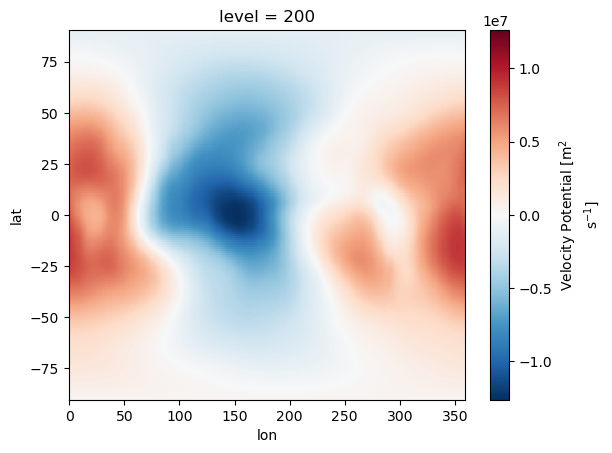

In [11]:
velocity_potential_climatology.isel(batch=0).mean(dim='time').plot()

In [ ]:
start_date = "2021-02-26T00"

def recalculate_timestamps(data, init_date)
    init_time = data.where(era5_data.datetime == np.datetime64(init_date), drop=True).time
    new_times = data.time.values - init_time.values
    retimed_data = data.assign_coords({'time':new_times})
    return retimed_data

In [ ]:
retimed_VP200 = calculate_velocity_potential_graphcast(retimed_data, level=200)
retimed_U200 = retimed_data['u_component_of_wind'].sel(level=200)
retimed_U850 = retimed_data['u_component_of_wind'].sel(level=850)

In [ ]:
meridionally_averaged_VP200 = retimed_VP200.sel(lat=slice(-15,15)).mean(dim='lat')
meridionally_averaged_U200 = retimed_U200.sel(lat=slice(-15,15)).mean(dim='lat')
meridionally_averaged_U850 = retimed_U850.sel(lat=slice(-15,15)).mean(dim='lat')

meridionally_averaged_VP200 = retimed_VP200.sel(lat=slice(-15,15)).mean(dim='lat')
meridionally_averaged_U200 = retimed_U200.sel(lat=slice(-15,15)).mean(dim='lat')
meridionally_averaged_U850 = retimed_U850.sel(lat=slice(-15,15)).mean(dim='lat')

In [ ]:
# or if it's a separate variable/scalar you already have in the pipeline
reference_date = np.datetime64(start_date)  # wherever `initial_date` comes from in your code
decoded_time = reference_date + meridionally_averaged_U850["time"].values.astype("timedelta64[ns]")
meridionally_averaged_U850_with_date = meridionally_averaged_U850.assign_coords(time=decoded_time)

In [ ]:
def remove_rolling_mean(data):
    data_with_date = data.assign_coords(time=decoded_time)
    time_resampled_data = data_with_date.resample({'time':'1D'}).mean(dim='time')
    data_anomalies = time_resampled_data - time_resampled_data.rolling(time=120, center=False).mean(dim='time')
    return data_anomalies

meridionally_averaged_U200_anomalies = remove_rolling_mean(meridionally_averaged_U200)
meridionally_averaged_U850_anomalies = remove_rolling_mean(meridionally_averaged_U850)
meridionally_averaged_VP200_anomalies = remove_rolling_mean(meridionally_averaged_VP200)

In [ ]:
hera_stds

In [ ]:

rescaled_VP200 = meridionally_averaged_U200_anomalies / hera_stds.sel(variable='VP200')
rescaled_U200 = meridionally_averaged_U850_anomalies / hera_stds.sel(variable='U200')
rescaled_U850 = meridionally_averaged_VP200_anomalies / hera_stds.sel(variable='U850')

In [ ]:
# hera_eofs = hera_eofs.rename({'u200':'U200', 'u850':'U850', 'vp200':'VP200'})
hera_eofs.attrs['std'] = [5.576273e+00, 1.853310e+00, 4.718959e+06]
hera_eofs.to_netcdf("/glade/u/home/sressel/spencer-scratch/VPM_EOFs_ERA-I_1990-2009.nc")

In [ ]:
hera_eofs = xr.open_dataset("/glade/u/home/sressel/spencer-scratch/eofev_VPM_ERA-I_1990-2009_.nc").isel(lev=0, lat=0, drop=True).rename({'time':'mode'}).assign_coords({'mode':[1,2,3,4,5]}).interp(lon=np.arange(0.0, 360.0, 1.0)).interpolate_na(dim='lon')
hera_eofs['u200'][:, -1] = (hera_eofs['u200'][:, -2] + hera_eofs['u200'][:, 0])/2
hera_eofs['u850'][:, -1] = (hera_eofs['u850'][:, -2] + hera_eofs['u850'][:, 0])/2
hera_eofs['vp200'][:, -1] = (hera_eofs['vp200'][:, -2] + hera_eofs['vp200'][:, 0])/2

hera_stds = xr.DataArray(
    data=np.array([5.576273, 1.853310, 4718959.]),
    dims='variable',
    coords={'variable':['U200', 'U850', 'VP200']}
)


concat_data = np.concat(
    [
        rescaled_U200.isel(batch=0, drop=True).values[10:],
        rescaled_U850.isel(batch=0, drop=True).values[10:],
        rescaled_VP200.isel(batch=0, drop=True).values[10:],    
    ],
    axis=1
)

concat_eofs = np.concat(
    [
        hera_eofs['u200'].sel(mode=[1,2]).values,
        hera_eofs['u850'].sel(mode=[1,2]).values,
        hera_eofs['vp200'].sel(mode=[1,2]).values,
    ],
    axis=1
)

In [ ]:
PCs = np.einsum('ij,kj->ik', concat_eofs, concat_data)
VPM1 = PCs[0]/np.std(PCs[0])
VPM2 = PCs[1]/np.std(PCs[0])
loss = VPM1 + VPM2
loss

In [ ]:
plt.plot(loss)

In [ ]:

# u850_norm = U850.sel(lat=slice(-15,15)).mean(dim='lat').isel(batch=0, drop=True).stats.standardize(zero_mean=False, unit_variance=True)
# u200_norm = U200.sel(lat=slice(-15,15)).mean(dim='lat').isel(batch=0, drop=True).stats.standardize(zero_mean=False, unit_variance=True)
# vp200_norm = VP200.sel(lat=slice(-15,15)).mean(dim='lat').isel(batch=0, drop=True).stats.standardize(zero_mean=False, unit_variance=True)

# u850_norm = U850.sel(lat=slice(-15,15)).mean(dim='lat').stats.standardize(zero_mean=False, unit_variance=True)
# u200_norm = U200.sel(lat=slice(-15,15)).mean(dim='lat').stats.standardize(zero_mean=False, unit_variance=True)
# vp200_norm = VP200.sel(lat=slice(-15,15)).mean(dim='lat').stats.standardize(zero_mean=False, unit_variance=True)

# multivariate_data = np.concatenate(
#     [
#         vp200_norm,
#         u850_norm,
#         u200_norm,
#     ], 
#     axis=1
# )

# multivariate_data = [
#     vp200_norm,
#     u850_norm,
#     u200_norm,
# ]

# model = xe.single.EOF(
#     n_modes=10,
#     standardize=False,   # set True if you want xeofs to z-score internally instead
#     # use_coslat=True,     # applies latitude weighting — recommended for lat/lon grids
# )
# model.fit(multivariate_data, dim="time")

# # Components and scores
# components = model.components()   # returns a list of DataArrays, one per input field
# scores = model.scores()           # combined PC time series (shared across variables)

# explained_var = model.explained_variance_ratio()
# logger.info("Finished")

# U, S, VT = np.linalg.svd(multivariate_data.T, full_matrices=False)
# EOF = U.T 
# PC = np.dot(np.diag(S), VT) 


In [ ]:
hera_eofs = xr.open_dataset("/glade/u/home/sressel/spencer-scratch/eofev_VPM_ERA-I_1990-2009_.nc").isel(lev=0, lat=0, drop=True).rename({'time':'mode'}).assign_coords({'mode':[1,2,3,4,5]}).interp(lon=np.arange(0.0, 366.0, 1.0))
hera_eofs['u200'].sel(mode=1).plot(x='lon')
hera_eofs['u850'].sel(mode=1).plot(x='lon')
hera_eofs['vp200'].sel(mode=1).plot(x='lon')

In [ ]:
hera_eofs_interpolated = hera_eofs.interp(lon=np.arange(0.0, 366.0, 1.0))
hera_eofs_interpolated['u200'].sel(mode=1).plot()
hera_eofs_interpolated['u850'].sel(mode=1).plot()
hera_eofs_interpolated['vp200'].sel(mode=1).plot()

In [ ]:
np.sqrt((xr.concat(
    [
        hera_eofs['u200'].sel(mode=5),
        hera_eofs['u850'].sel(mode=5),
        hera_eofs['vp200'].sel(mode=5)
    ],
    dim='lon'
)**2).sum())

In [ ]:
from auxiliary_functions.mjo_mean_state_diagnostics import remove_annual_cycle
import numpy as np

VP200_merid = VP200.sel(lat=slice(-15,15)).mean(dim='lat')
U200_merid = U200.sel(lat=slice(-15,15)).mean(dim='lat')
U850_merid = U850.sel(lat=slice(-15,15)).mean(dim='lat')

VP200_deano, _ = remove_annual_cycle(VP200_merid, nharmonics=4)
U200_deano, _ = remove_annual_cycle(U200_merid, nharmonics=4)
U850_deano, _ = remove_annual_cycle(U850_merid, nharmonics=4)

VP200_highpass = VP200_deano - VP200_deano.rolling(time=120, center=False).mean()
U200_highpass = U200_deano - U200_deano.rolling(time=120, center=False).mean()
U850_highpass = U850_deano - U850_deano.rolling(time=120, center=False).mean()

VP200_highpass_norm = np.sqrt(VP200_highpass.var(dim='time').mean(dim='lon'))
U200_highpass_norm = np.sqrt(U200_highpass.var(dim='time').mean(dim='lon'))
U850_highpass_norm = np.sqrt(U850_highpass.var(dim='time').mean(dim='lon'))

VP200_highpass_std = VP200_highpass / VP200_highpass_norm
U200_highpass_std = U200_highpass / U200_highpass_norm
U850_highpass_std = U850_highpass / U850_highpass_norm

multivariate_data = [
    VP200_highpass_std,
    U200_highpass_std,
    U850_highpass_std,
]

model = xe.single.EOF(
    n_modes=10,
    standardize=False,   # set True if you want xeofs to z-score internally instead
    # use_coslat=True,     # applies latitude weighting — recommended for lat/lon grids
)
model.fit(multivariate_data, dim="time")

# Components and scores
components = model.components()   # returns a list of DataArrays, one per input field
scores = model.scores()           # combined PC time series (shared across variables)


In [ ]:
VP200_new_highpass
U200_new_highpass
U850_new_highpass

VP200_new_std = VP200_new_highpass / vp200_norm
U200_new_std  = U200_new_highpass  / u200_norm
U850_new_std  = U850_new_highpass  / u850_norm

new_multivariate = [VP200_new_std, U200_new_std, U850_new_std]
new_scores = model.transform(new_multivariate)

In [ ]:
import matplotlib.pyplot as plt 

VP200_EOF = components[0]
U200_EOF = components[1]
U850_EOF = components[2]

[fig, ax] = plt.subplots(3, 1, figsize=(9,16))

VP200_EOF.sel(mode=1).plot(ax=ax[0], color='k')
U200_EOF.sel(mode=1).plot(ax=ax[0], color='k', ls=':')
U850_EOF.sel(mode=1).plot(ax=ax[0], color='k', ls='--')
ax[0].axhline(y=0, color='k', lw=1)

VP200_EOF.sel(mode=2).plot(ax=ax[1], color='k')
U200_EOF.sel(mode=2).plot(ax=ax[1], color='k', ls=':')
U850_EOF.sel(mode=2).plot(ax=ax[1], color='k', ls='--')
ax[1].axhline(y=0, color='k', lw=1)

VP200_EOF.sel(mode=3).plot(ax=ax[2], color='k')
U200_EOF.sel(mode=3).plot(ax=ax[2], color='k', ls=':')
U850_EOF.sel(mode=3).plot(ax=ax[2], color='k', ls='--')
ax[2].axhline(y=0, color='k', lw=1)

plt.show()

In [ ]:
VP200_new = xr.open_dataset("/glade/u/home/sressel/spencer-scratch/ECMWF/ERA5/daily_data/daily_25_degree_meridional_wind_1980_2018.nc")['v'].sel(plev=200, drop=True).sel(time=slice('2010-01-01T00:00:00.000000000', '2010-01-31T00:00:00.000000000'))

U200_new = xr.open_dataset("/glade/u/home/sressel/spencer-scratch/ECMWF/ERA5/daily_data/daily_25_degree_zonal_wind_1980_2018.nc")['u'].sel(plev=200, drop=True).sel(time=slice('2010-01-01T00:00:00.000000000', '2010-01-31T00:00:00.000000000'))

U850_new = xr.open_dataset("/glade/u/home/sressel/spencer-scratch/ECMWF/ERA5/daily_data/daily_25_degree_zonal_wind_1980_2018.nc")['u'].sel(plev=850, drop=True).sel(time=slice('2010-01-01T00:00:00.000000000', '2010-01-31T00:00:00.000000000'))

VP200_merid_new = VP200_new.sel(lat=slice(-15,15)).mean(dim='lat')
U200_merid_new = U200_new.sel(lat=slice(-15,15)).mean(dim='lat')
U850_merid_new = U850_new.sel(lat=slice(-15,15)).mean(dim='lat')


VP200_deano_new, _ = apply_annual_cycle(VP200_merid_new, VP200_coeffs, VP200_t0, nharmonics=4)

In [ ]:
def subtract_120day_sliding_mean(merged_array):
    out = []
    for i in range(120, merged_array.shape[0]):
        past_mean = np.nanmean(merged_array[i-120:i], axis=0)
        anom = merged_array[i] - past_mean
        out.append(anom)
    return np.stack(out)

In [ ]:
plt.plot(vp_EOF[0])
plt.plot(vp_EOF[1])
plt.plot(vp_EOF[2])

In [ ]:
components[0].sel(mode=1).plot(color='k')
components[1].sel(mode=1).plot()
components[2].sel(mode=1).plot()

In [ ]:
# Configure plot
# import seaborn as sns
plt.style.use('default')
[fig, ax] = plt.subplots(1, 2, figsize=(12,6))
# plt.xlabel("RMM1")
# plt.ylabel("RMM2")

# Plot index points
# colormap = sns.color_palette("viridis", as_cmap=True)

# start_time = '1992-02-12' 
# end_time = '1992-05-12'

# start_time = '1992-08-14' 
# end_time = '1992-11-12'

# start_time = np.datetime64("1975-04-01T00:00:00.000000000")
# end_time = np.datetime64("1975-04-30T00:00:00.000000000")

# start_time = '1975-02-24T00:00:00.000000000'
# end_time = '1975-04-11T00:00:00.000000000'

# start_time="2020-12-29T00:00:00.000000000"
# end_time="2021-02-27T00:00:00.000000000"

start_time = 0
end_time = 2138400000000000

# start_time = primary_event_start_times[-1].values
# end_time = primary_event_end_times[-1].values

# for index, (start_time, end_time) in enumerate(zip(('1992-02-12', '1992-08-14'), ('1992-05-12', '1992-11-12'))):


# for time in principle_components.time.sel(time=slice(start_time, end_time)):
ax[index].plot(
    principle_components.sel(mode=1).isel(time=slice(start_time, end_time)),
    principle_components.sel(mode=2).isel(time=slice(start_time, end_time)),
    color='k',
    linestyle='-',
    marker=".",
    ms=8,
)

# Add phase regions overlay
circle1 = plt.Circle((0, 0), 0.3, color="#bcbcbc", fill=False, lw=1, zorder=10)
circle2 = plt.Circle((0, 0), 0.4, color="k", fill=False, lw=1.5, zorder=10)
circle3 = plt.Circle((0, 0), 0.5, color="#bcbcbc", fill=False, lw=1, zorder=10)
ax[index].add_patch(circle1)
ax[index].add_patch(circle2)
ax[index].add_patch(circle3)

ax[index].axhline(y=0, color="k", lw=1, ls="-")
ax[index].axvline(x=0, color="k", lw=1, ls="-")

# Add lines to differentiate the phases
ax[index].plot(
    [0.4*np.cos(np.deg2rad(45)), 10*np.cos(np.deg2rad(45))],
    [0.4*np.sin(np.deg2rad(45)), 10*np.sin(np.deg2rad(45))],
    color="k",
    lw=1,
    ls="-"
)
ax[index].plot(
    [0.4*np.cos(np.deg2rad(45)), 10*np.cos(np.deg2rad(45))],
    [-0.4*np.sin(np.deg2rad(45)), -10*np.sin(np.deg2rad(45))],
    color="k",
    lw=1,
    ls="-"
)
ax[index].plot(
    [-0.4*np.cos(np.deg2rad(45)), -10*np.cos(np.deg2rad(45))],
    [-0.4*np.sin(np.deg2rad(45)), -10*np.sin(np.deg2rad(45))],
    color="k",
    lw=1,
    ls="-"
)
ax[index].plot(
    [-0.4*np.cos(np.deg2rad(45)), -10*np.cos(np.deg2rad(45))],
    [0.4*np.sin(np.deg2rad(45)), 10*np.sin(np.deg2rad(45))],
    color="k",
    lw=1,
    ls="-"
)

ax[index].set_xlim(-3,3)
ax[index].set_ylim(-3,3)

# # Add phase labels
ax[index].text(
    2.9, 0.1,
    f'Category A',
    horizontalalignment='right',
    verticalalignment='center',
    fontsize=12
)
ax[index].text(
    0, 2.8,
    f'Category B',
    horizontalalignment='center',
    verticalalignment='center',
    fontsize=12
)
ax[index].text(
    -2.9, .1,
    f'Category C',
    horizontalalignment='left',
    verticalalignment='center',
    fontsize=12
)
ax[index].text(
    0, -2.8,
    f'Category D',
    horizontalalignment='center',
    verticalalignment='center',
    fontsize=12
)

ax[index].spines['left'].set_position('zero')
ax[index].spines['bottom'].set_position('zero')

# Hide the top and right spines
ax[index].spines['right'].set_color('none')
ax[index].spines['top'].set_color('none')

# Ensure tick marks follow the spines to the center
ax[index].xaxis.set_ticks_position('bottom')
ax[index].yaxis.set_ticks_position('left')

ax[index].set_aspect("equal")
plt.tight_layout()

In [ ]:
principle_components.time

In [ ]:
xr.open_dataset("/glade/u/home/sressel/spencer-scratch/graphcast_input_data/daily_climatology/2004/u_component_of_wind.nc")

In [ ]:
test = xr.open_dataset("/glade/u/home/sressel/spencer-scratch/graphcast_input_data/2020-09_2021-02/era5_data.nc")
new_wind = xr.zeros_like(test)
new_wind[:] = test['u_component_of_wind'].values * np.random.rand(*test['u_component_of_wind'].shape)
new_wind

In [ ]:
np.random.rand(*test['u_component_of_wind'].shape)

In [ ]:
era5_data = xr.open_dataset("/glade/u/home/sressel/spencer-scratch/graphcast_input_data/2020-05_2021-02/era5_data.nc")
# init_time = era5_data.where(era5_data.datetime == np.datetime64("2021-01-01T00")).dropna(dim='time').time


In [ ]:
era5_data.time.print()

In [ ]:
values, counts = np.unique(era5_data.time, return_counts=True)
counts

In [ ]:
data_directory = "/glade/u/home/sressel/spencer-scratch/graphcast_input_data/2017-07_2017-12/"
era5_data = xr.open_dataset(f"{data_directory}/era5_data.nc")
new_times = np.arange(0, (np.shape(era5_data.datetime)[1])*21600000000000, 21600000000000, dtype='timedelta64[ns]')
new_era5_data = era5_data.assign_coords({'time':new_times})
new_era5_data.time.encoding = {}   # clear any leftover encoding info
new_era5_data.time.attrs = {}      # clear any leftover attrs, if you don't need them
new_era5_data.to_netcdf(f"{data_directory}/era5_data_temp.nc")

In [ ]:
new_test = xr.open_dataset(f"{data_directory}/era5_data_temp.nc", decode_times=False)
del new_test.time.attrs['dtype']
new_test.to_netcdf(f"{data_directory}/era5_data_fixed.nc")

In [ ]:
# data_directory = "/glade/u/home/sressel/spencer-scratch/graphcast_input_data/2017-07_2017-12/"
# # data_directory = "/glade/u/home/sressel/spencer-scratch/graphcast_input_data/2020-05_2021-02/"
# xr.open_dataset(f"{data_directory}/era5_data.nc").isel(batch=0, drop=True).datetime.values

xr.open_dataset("/glade/u/home/sressel/spencer-scratch/graphcast_input_data/2017-07_2017-12/2m_temperature.nc").datetime.values

In [ ]:
# len(np.unique(era5_data.time)) == len(era5_data.time)
len(np.unique(new_era5_data.time)) == len(new_era5_data.time)

In [ ]:
new_era5_data.time.encoding

In [ ]:
xr.open_dataset("/glade/u/home/sressel/spencer-scratch/graphcast_input_data/2020-05_2021-02/era5_data_fixed.nc")

In [ ]:
# era5_data.sel(time=test.time[0])
test.time[0].values
era5_data.sel(time='2678400000000000')

In [ ]:
# vars_to_keep = ['u_component_of_wind', 'v_component_of_wind']
predictions = xr.open_dataset("/glade/u/home/sressel/spencer-scratch/graphcast_input_data/2020-09_2021-02/era5_data.nc")
# predictions = predictions.drop_vars([var for var in predictions.data_vars if var not in vars_to_keep])
predictions = predictions.drop_vars(['number', 'expver', 'datetime'])
targets = xr.zeros_like(predictions)
for var in predictions.data_vars:
    logger.info(var)
    if var not in ['geopotential_at_surface', 'land_sea_mask']:
        targets[var][:] =  (
            predictions[var].values
            + np.random.normal(predictions[var].mean().values, predictions[var].std().values, size=predictions[var].shape)
        )
    else:
        targets[var][:] =  predictions[var].values

logger.info("Finished")

In [ ]:
predictions

In [ ]:
init_date = "2021-01-01"

from auxiliary_functions import calculate_velocity_potential_graphcast

meridional_mean_climatological_data = xr.open_dataset(
    "/glade/u/home/sressel/spencer-scratch/graphcast_input_data/daily_climatology/climatology_for_graphcast.nc"
)

def recalculate_timestamps(data, init_date):
    init_time = data.where(data.datetime == np.datetime64(init_date), drop=True).time
    new_times = data.time.values - init_time.values
    retimed_data = data.assign_coords({'time':new_times})
    return retimed_data

def remove_rolling_mean(data, init_date):
    reference_date = np.datetime64(init_date)  
    decoded_time = reference_date + data["time"].values.astype("timedelta64[ns]")
    data_with_date = data.assign_coords(time=decoded_time)

    time_resampled_data = data_with_date.resample({'time':'1D'}).mean(dim='time')
    data_anomalies = time_resampled_data - time_resampled_data.rolling(
        time=120, center=False
    ).mean(dim='time')
    return data_anomalies

# Load in the climatological data for a given init_date
meridional_mean_climatology = xr.open_dataset(
    "/glade/u/home/sressel/spencer-scratch/graphcast_input_data/daily_climatology/climatology_for_graphcast.nc"
)

rolling_mean_climatology = xr.open_dataset(
    "/glade/u/home/sressel/spencer-scratch/graphcast_input_data/2020-05_2021-02/era5_data.nc"
)

# Rewrite the timestamps on the climatological data to match the predictions
rolling_mean_climatology = recalculate_timestamps(rolling_mean_climatology, init_date)

# Append the graphcast predictions to the climatological data
predictions_appended = xr.concat(
    [rolling_mean_climatology, predictions],
    dim='time'
)

# Append the graphcast predictions to the climatological data
targets_appended = xr.concat(
    [rolling_mean_climatology, targets],
    dim='time'
)

# Extract U200 and U850 from meridionally averaged data
U200_predictions = predictions_appended['u_component_of_wind'].sel(level=200)
U200_targets = targets_appended['u_component_of_wind'].sel(level=200)

U850_predictions = predictions_appended['u_component_of_wind'].sel(level=850)
U850_targets = targets_appended['u_component_of_wind'].sel(level=850)

# Calculate velocity potential for the predictions and targets
VP200_predictions = calculate_velocity_potential_graphcast(
    predictions_appended
)
VP200_targets = calculate_velocity_potential_graphcast(
    targets_appended
)

# Meridionally average targets and predictions
meridionally_averaged_U200_predictions = U200_predictions.sel(
    lat=slice(-15,15)
).mean(dim='lat')
meridionally_averaged_U850_predictions = U850_predictions.sel(
    lat=slice(-15,15)
).mean(dim='lat')
meridionally_averaged_VP200_predictions = VP200_predictions.sel(
    lat=slice(-15,15)
).mean(dim='lat')

meridionally_averaged_U200_targets = U200_targets.sel(
    lat=slice(-15,15)
).mean(dim='lat')
meridionally_averaged_U850_targets = U850_targets.sel(
    lat=slice(-15,15)
).mean(dim='lat')
meridionally_averaged_VP200_targets = VP200_targets.sel(
    lat=slice(-15,15)
).mean(dim='lat')

climatology = xr.open_dataset("")

# Remove 120-rolling mean climatology from the variables
U200_prediction_anomalies = remove_rolling_mean(
    meridionally_averaged_U200_predictions,
    init_date
)
U200_target_anomalies = remove_rolling_mean(
    meridionally_averaged_U200_targets,
    init_date
)
U850_prediction_anomalies = remove_rolling_mean(
    meridionally_averaged_U850_predictions,
    init_date
)
U850_target_anomalies = remove_rolling_mean(
    meridionally_averaged_U850_targets,
    init_date
)
VP200_prediction_anomalies = remove_rolling_mean(
    meridionally_averaged_VP200_predictions,
    init_date
)
VP200_target_anomalies = remove_rolling_mean(
    meridionally_averaged_VP200_targets,
    init_date
)

VPM_EOF_filepath = "/glade/u/home/sressel/spencer-scratch/VPM_EOFs_ERA-I_1990-2009.nc"
EOFs = xr.open_dataset(VPM_EOF_filepath).isel(
    lev=0, lat=0, drop=True
).rename(
    {'time':'mode'}
).assign_coords(
    {'mode':[1,2,3,4,5]}
).interp(
    lon=np.arange(0.0, 360.0, 1.0)
).interpolate_na(dim='lon')
EOFs['U200'][:, -1] = (EOFs['U200'][:, -2] + EOFs['U200'][:, 0])/2
EOFs['U850'][:, -1] = (EOFs['U850'][:, -2] + EOFs['U850'][:, 0])/2
EOFs['VP200'][:, -1] = (EOFs['VP200'][:, -2] + EOFs['VP200'][:, 0])/2

concatenated_eofs = np.concat(
    [
        EOFs['U200'].sel(mode=[1,2]).values,
        EOFs['U850'].sel(mode=[1,2]).values,
        EOFs['VP200'].sel(mode=[1,2]).values,
    ],
    axis=1
)

standard_deviations = EOFs.attrs['std']

U200_prediction_anomalies_rescaled = (
    U200_prediction_anomalies / standard_deviations[0]
)
U200_target_anomalies_rescaled = (
    U200_target_anomalies / standard_deviations[0]
)
U850_prediction_anomalies_rescaled = (
    U850_prediction_anomalies / standard_deviations[1]
)
U850_target_anomalies_rescaled = (
    U850_target_anomalies / standard_deviations[1]
)
VP200_prediction_anomalies_rescaled = (
    VP200_prediction_anomalies / standard_deviations[2]
)
VP200_target_anomalies_rescaled = (
    VP200_target_anomalies / standard_deviations[2]
)

predictions_concatenated = np.concat(
    [
        U200_prediction_anomalies_rescaled.isel(batch=0, drop=True).values,
        U850_prediction_anomalies_rescaled.isel(batch=0, drop=True).values,
        VP200_prediction_anomalies_rescaled.isel(batch=0, drop=True).values,    
    ],
    axis=1
)

targets_concatenated = np.concat(
    [
        U200_target_anomalies_rescaled.isel(batch=0, drop=True).values,
        U850_target_anomalies_rescaled.isel(batch=0, drop=True).values,
        VP200_target_anomalies_rescaled.isel(batch=0, drop=True).values,    
    ],
    axis=1
)

difference_PCs = np.einsum(
    'ij,kj->ik', 
    concatenated_eofs, 
    (predictions_concatenated - targets_concatenated)
)
difference_VPM1 = difference_PCs[0]/np.std(difference_PCs[0])
difference_VPM2 = difference_PCs[1]/np.std(difference_PCs[0])

losses = np.sqrt(difference_VPM1**2 + difference_VPM2**2)